# Hydro-Sense — Deep Learning avec Darts (Google Colab)

**Projet Le Wagon Data Science & AI — Nantes, juin 2026**

---

## Objectif
Tester les modèles deep learning de Darts sur le piézomètre de Bourdet.
Ces modèles nécessitent PyTorch — trop lourd en local, on tourne sur Colab (GPU gratuit).

## Modèles testés
| Modèle | Description |
|---|---|
| **N-BEATS** | Spécialisé séries temporelles, pas besoin de covariables |
| **TCN** | Temporal Convolutional Network — longues dépendances |
| **LSTM** | Classique deep learning temporel |

## Référence à battre (résultats du notebook local)
```
Saisonnier       MAE=0.256  RMSE=0.288  R²=0.512  <- baseline
LinearRegression MAE=0.272  RMSE=0.312  R²=0.425
```

> **Avant de lancer** : activer le GPU dans Colab
> `Exécution > Modifier le type d'exécution > GPU`

---
## 1. Installation des dépendances

On installe Darts avec le support PyTorch (torch). Prend ~3 minutes sur Colab.

In [1]:
!pip install "darts[torch]" -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.7/65.7 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.0/58.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 396.0/396.0 kB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 825.4/825.4 kB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.9/780.9 kB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 38.8 MB/s eta 0:00:00


---
## 2. Chargement des données

Deux options :
- **Option A** : uploader le CSV depuis ton ordinateur
- **Option B** : monter Google Drive si le CSV est dessus

In [2]:
# Option A — Upload manuel
from google.colab import files
uploaded = files.upload()  # sélectionner piezo_bourdet_clean.csv

Saving piezo_bourdet_clean.csv to piezo_bourdet_clean.csv


In [ ]:
# Option B — Google Drive
# from google.colab import drive
# drive.mount('/content/drive')
# CSV_PATH = "/content/drive/MyDrive/hydrosense/piezo_bourdet_clean.csv"

Période : 1994-02-01 -> 2026-05-30
Jours   : 11807


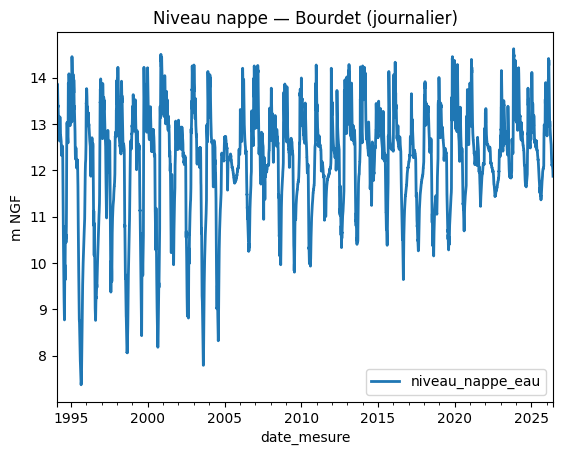

In [3]:
import pandas as pd
from darts import TimeSeries
import matplotlib.pyplot as plt

# Charger le CSV (Option A)
df = pd.read_csv("piezo_bourdet_clean.csv")
df["date_mesure"] = pd.to_datetime(df["date_mesure"])
df = df.set_index("date_mesure").sort_index()

# TimeSeries Darts journalière
ts = TimeSeries.from_series(df["niveau_nappe_eau"], freq="D")

print(f"Période : {ts.start_time().date()} -> {ts.end_time().date()}")
print(f"Jours   : {len(ts)}")

ts.plot()
plt.title("Niveau nappe — Bourdet (journalier)")
plt.ylabel("m NGF")
plt.show()

---
## 3. Split Train / Val

Même découpage que le notebook local :
```
TRAIN : 1994-02-01 -> 2026-02-28  (~32 ans)
VAL   : 2026-03-01 -> 2026-05-30  (~3 mois)
```

In [4]:
ts_train, ts_val = ts.split_before(pd.Timestamp("2026-03-01"))

print(f"TRAIN : {ts_train.start_time().date()} -> {ts_train.end_time().date()}  ({len(ts_train)} jours)")
print(f"VAL   : {ts_val.start_time().date()} -> {ts_val.end_time().date()}    ({len(ts_val)} jours)")

TRAIN : 1994-02-01 -> 2026-02-28  (11716 jours)
VAL   : 2026-03-01 -> 2026-05-30    (91 jours)


---
## 4. Baseline Saisonnier (référence)

On recrée le baseline saisonnier pour avoir la référence à battre directement dans ce notebook.

In [5]:
from darts.models import NaiveSeasonal
from darts.metrics import mae, rmse, mape, r2_score

model_seasonal = NaiveSeasonal(K=365)
model_seasonal.fit(ts_train)
pred_seasonal = model_seasonal.predict(90)

print(f"Saisonnier — MAE={mae(ts_val[:90], pred_seasonal):.3f}  RMSE={rmse(ts_val[:90], pred_seasonal):.3f}  R²={r2_score(ts_val[:90], pred_seasonal):.3f}")

Saisonnier — MAE=0.256  RMSE=0.288  R²=0.512


---
## 5. N-BEATS

**N-BEATS** (Neural Basis Expansion Analysis for Time Series) est un modèle
deep learning spécialement conçu pour les séries temporelles.

**Avantages pour Hydro-Sense :**
- Pas besoin de covariables — apprend les patterns directement depuis la série
- Très bon sur les longues séries avec saisonnalité forte
- Interprétable : sépare tendance et saisonnalité

**Paramètres clés :**
- `input_chunk_length` : fenêtre d'entrée — on met 365 (1 an de mémoire)
- `output_chunk_length` : horizon de prédiction — on met 90 (3 mois)
- `n_epochs` : nombre de passes d'entraînement

GPU disponible : True


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | stacks          | ModuleList       | 8.9 M  | train
-------------------------------------------------------------
8.9 M     Trainable params
3.5 K     Non-trainable params
8.9 M     Total params
35.565    Total estimated m

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=50` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]


=== N-BEATS ===
MAE   : 0.342 m
RMSE  : 0.427 m
MAPE  : 2.77 %
R²    : -0.075


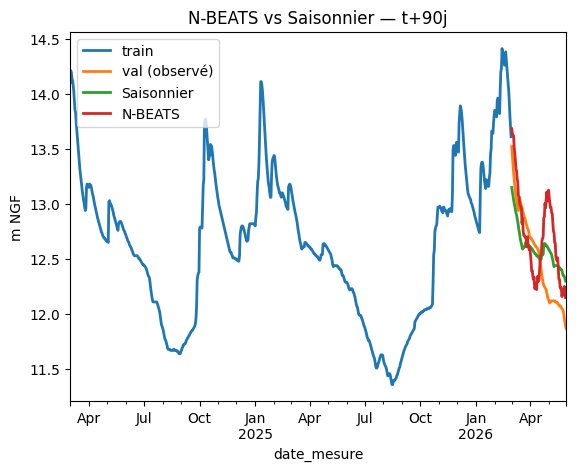

In [6]:
import torch
from darts.models import NBEATSModel

print(f"GPU disponible : {torch.cuda.is_available()}")

model_nbeats = NBEATSModel(
    input_chunk_length=365,   # 1 an de mémoire
    output_chunk_length=90,   # prédit 90 jours d'un coup
    n_epochs=50,
    batch_size=32,
    random_state=42,
)

model_nbeats.fit(ts_train, verbose=True)
pred_nbeats = model_nbeats.predict(90)

print("\n=== N-BEATS ===")
print(f"MAE   : {mae(ts_val[:90], pred_nbeats):.3f} m")
print(f"RMSE  : {rmse(ts_val[:90], pred_nbeats):.3f} m")
print(f"MAPE  : {mape(ts_val[:90], pred_nbeats):.2f} %")
print(f"R²    : {r2_score(ts_val[:90], pred_nbeats):.3f}")

ts_train[-730:].plot(label="train")
ts_val.plot(label="val (observé)")
pred_seasonal.plot(label="Saisonnier")
pred_nbeats.plot(label="N-BEATS")
plt.title("N-BEATS vs Saisonnier — t+90j")
plt.ylabel("m NGF")
plt.legend()
plt.show()

---
## 6. TCN — Temporal Convolutional Network

**TCN** utilise des convolutions dilatées pour capturer des dépendances à long terme
sans les problèmes de gradient des RNN/LSTM.

Bien adapté aux longues séries avec des patterns complexes.

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | res_blocks      | ModuleList       | 392    | train
-------------------------------------------------------------
392       Trainable params
0         Non-trainable params
392       Total params
0.002     Total estimated m

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=50` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]


=== TCN ===
MAE   : 0.427 m
RMSE  : 0.462 m
MAPE  : 3.39 %
R²    : -0.259


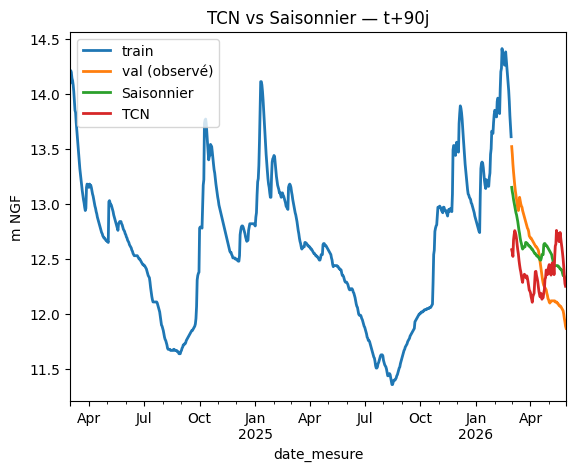

In [7]:
from darts.models import TCNModel

model_tcn = TCNModel(
    input_chunk_length=365,
    output_chunk_length=90,
    n_epochs=50,
    batch_size=32,
    random_state=42,
)

model_tcn.fit(ts_train, verbose=True)
pred_tcn = model_tcn.predict(90)

print("\n=== TCN ===")
print(f"MAE   : {mae(ts_val[:90], pred_tcn):.3f} m")
print(f"RMSE  : {rmse(ts_val[:90], pred_tcn):.3f} m")
print(f"MAPE  : {mape(ts_val[:90], pred_tcn):.2f} %")
print(f"R²    : {r2_score(ts_val[:90], pred_tcn):.3f}")

ts_train[-730:].plot(label="train")
ts_val.plot(label="val (observé)")
pred_seasonal.plot(label="Saisonnier")
pred_tcn.plot(label="TCN")
plt.title("TCN vs Saisonnier — t+90j")
plt.ylabel("m NGF")
plt.legend()
plt.show()

---
## 7. LSTM

**LSTM** (Long Short-Term Memory) est le classique du deep learning temporel.
Il mémorise les dépendances à long terme via des cellules mémoire.

Dans Darts il s'appelle `RNNModel` avec `model='LSTM'`.

In [8]:
from darts.models import RNNModel

model_lstm = RNNModel(
    model="LSTM",
    input_chunk_length=365,
    training_length=400,
    n_epochs=50,
    batch_size=32,
    random_state=42,
)

model_lstm.fit(ts_train, verbose=True)
pred_lstm = model_lstm.predict(90)

print("\n=== LSTM ===")
print(f"MAE   : {mae(ts_val[:90], pred_lstm):.3f} m")
print(f"RMSE  : {rmse(ts_val[:90], pred_lstm):.3f} m")
print(f"MAPE  : {mape(ts_val[:90], pred_lstm):.2f} %")
print(f"R²    : {r2_score(ts_val[:90], pred_lstm):.3f}")

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | LSTM             | 2.8 K  | train
6 | V               | Linear           | 26     | train
-------------------------------------------------------------
2.8 K     Trainable params
0         Non-trainable p

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=50` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]


=== LSTM ===
MAE   : 0.773 m
RMSE  : 0.855 m
MAPE  : 6.27 %
R²    : -3.305


---
## 8. Tableau comparatif final

Modèle                       MAE   RMSE    MAPE      R²
-------------------------------------------------------
Saisonnier                 0.256  0.288   2.06%   0.512
N-BEATS                    0.342  0.427   2.77%  -0.075
TCN                        0.427  0.462   3.39%  -0.259
LSTM                       0.773  0.855   6.27%  -3.305


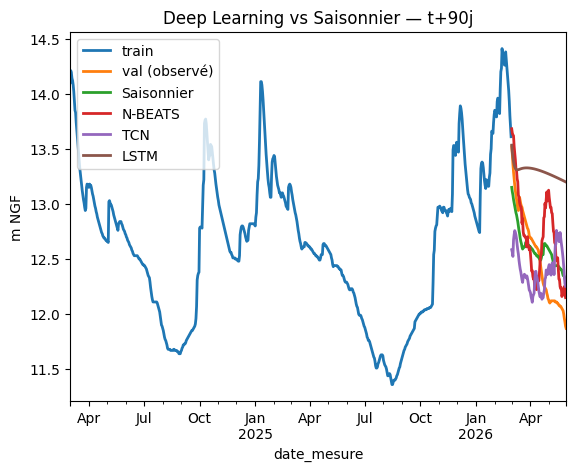

In [9]:
print(f"{'Modèle':<25} {'MAE':>6} {'RMSE':>6} {'MAPE':>7} {'R²':>7}")
print("-" * 55)
for name, pred in [
    ("Saisonnier",   pred_seasonal),
    ("N-BEATS",      pred_nbeats),
    ("TCN",          pred_tcn),
    ("LSTM",         pred_lstm),
]:
    print(f"{name:<25} {mae(ts_val[:90], pred):>6.3f} {rmse(ts_val[:90], pred):>6.3f} {mape(ts_val[:90], pred):>6.2f}% {r2_score(ts_val[:90], pred):>7.3f}")

# Courbes
ts_train[-730:].plot(label="train")
ts_val.plot(label="val (observé)")
pred_seasonal.plot(label="Saisonnier")
pred_nbeats.plot(label="N-BEATS")
pred_tcn.plot(label="TCN")
pred_lstm.plot(label="LSTM")
plt.title("Deep Learning vs Saisonnier — t+90j")
plt.ylabel("m NGF")
plt.legend()
plt.show()

In [10]:
from darts.metrics import mae, rmse, r2_score
import pandas as pd

horizons = {"J+15": 15, "J+30": 30, "J+90": 90}

modeles = {
    "Saisonnier":  model_seasonal,
    "N-BEATS":     model_nbeats,
    "TCN":         model_tcn,
    "LSTM":        model_lstm,
}

# Construire le DataFrame
rows = []
for nom, model in modeles.items():
    row = {"Modèle": nom}
    for h_name, h_val in horizons.items():
        pred_h = model.predict(h_val)
        row[f"{h_name}_MAE"] = round(mae(ts_val[:h_val], pred_h), 3)
        row[f"{h_name}_R²"]  = round(r2_score(ts_val[:h_val], pred_h), 3)
    rows.append(row)

df_scores = pd.DataFrame(rows).set_index("Modèle")

display(df_scores.style
    .format("{:.3f}")
    .background_gradient(subset=["J+15_R²", "J+30_R²", "J+90_R²"], cmap="RdYlGn")
    .background_gradient(subset=["J+15_MAE", "J+30_MAE", "J+90_MAE"], cmap="RdYlGn_r")
)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


...

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

,J+15_MAE,J+15_R²,J+30_MAE,J+30_R²,J+90_MAE,J+90_R²
Modèle,,,,,,
Saisonnier,0.227,-0.889,0.232,-0.532,0.256,0.512
N-BEATS,0.206,-0.623,0.167,0.132,0.342,-0.075
TCN,0.545,-9.781,0.542,-6.883,0.427,-0.259
LSTM,0.206,-0.790,0.335,-2.477,0.773,-3.305
